In [1]:
import pandas as pd
import numpy as np

In [30]:
df = pd.read_csv("../EDA/transformed_load.csv", index_col=["Datetime"], parse_dates=["Datetime"])

In [3]:
df.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


In [4]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [5]:
print(df.info())
print(df.describe())
print("Shape",df.shape)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-12-31 01:00:00 to 2018-01-02 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB
None
             PJME_MW
count  145366.000000
mean    32080.222831
std      6464.012166
min     14544.000000
25%     27573.000000
50%     31421.000000
75%     35650.000000
max     62009.000000
Shape (145366, 1)


In [6]:
df.rename(columns={"PJME_MW": "load"}, inplace=True)
df.sort_index(inplace=True)
df.head()

,load
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [7]:
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')   

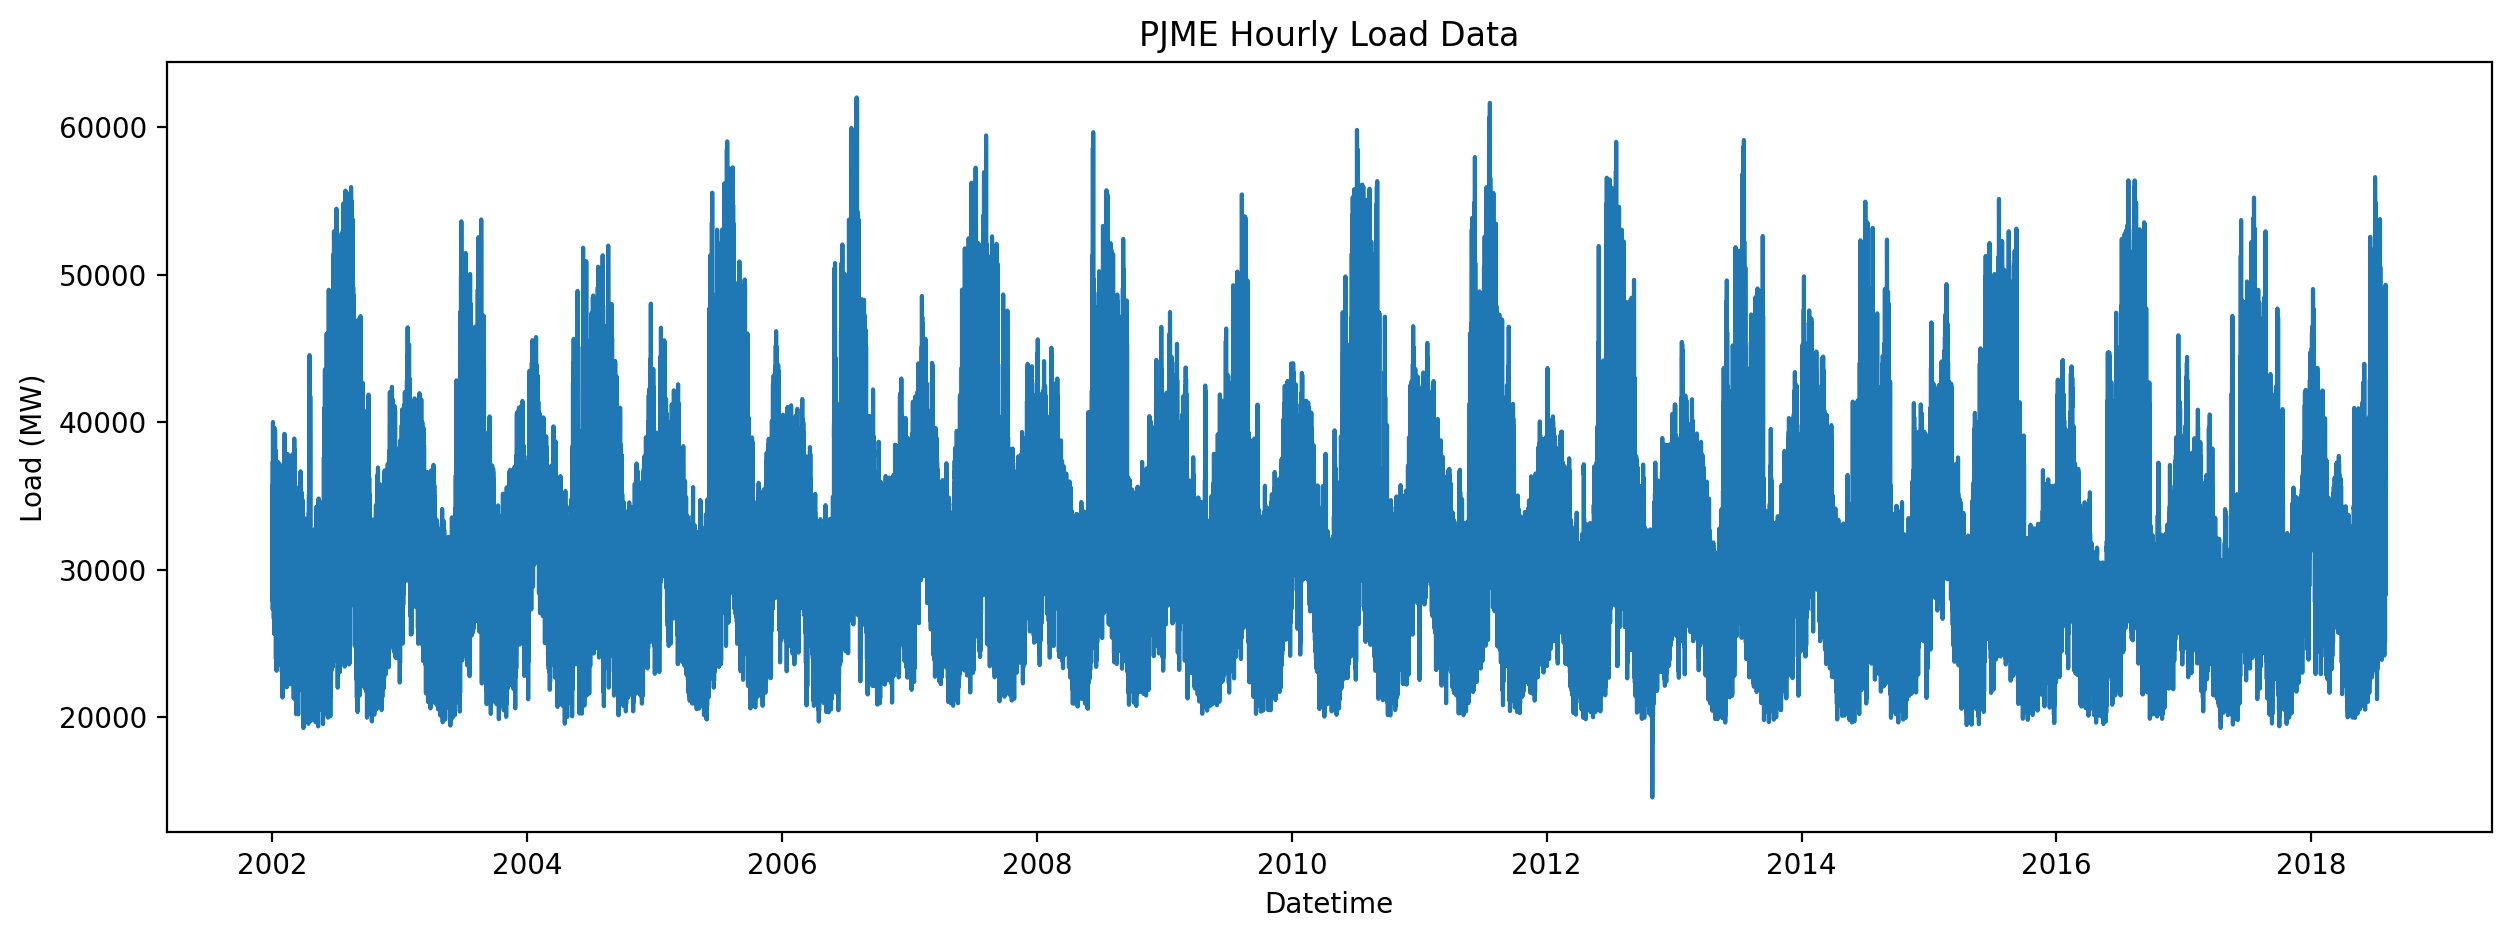

In [8]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df["load"])
plt.title("PJME Hourly Load Data")
plt.xlabel("Datetime")
plt.ylabel("Load (MW)")
plt.show()

In [9]:
print(df.isnull().sum())
print(df.index.duplicated().any()) 
np.True_
print(df.index.min(), df.index.max()) 

load    0
dtype: int64
True
2002-01-01 01:00:00 2018-08-03 00:00:00


In [10]:
df = df.loc[~df.index.duplicated(keep='first')]

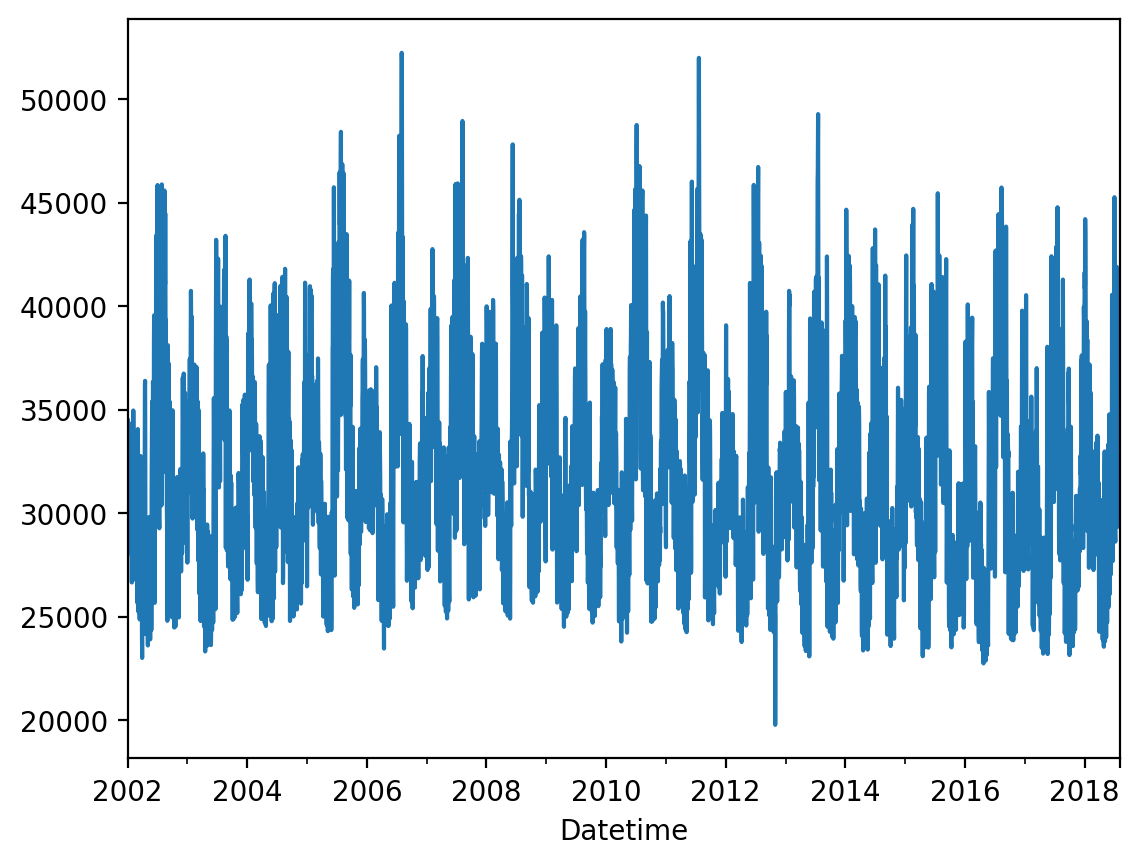

In [11]:
df["load"].resample('D').mean().plot()
plt.show()

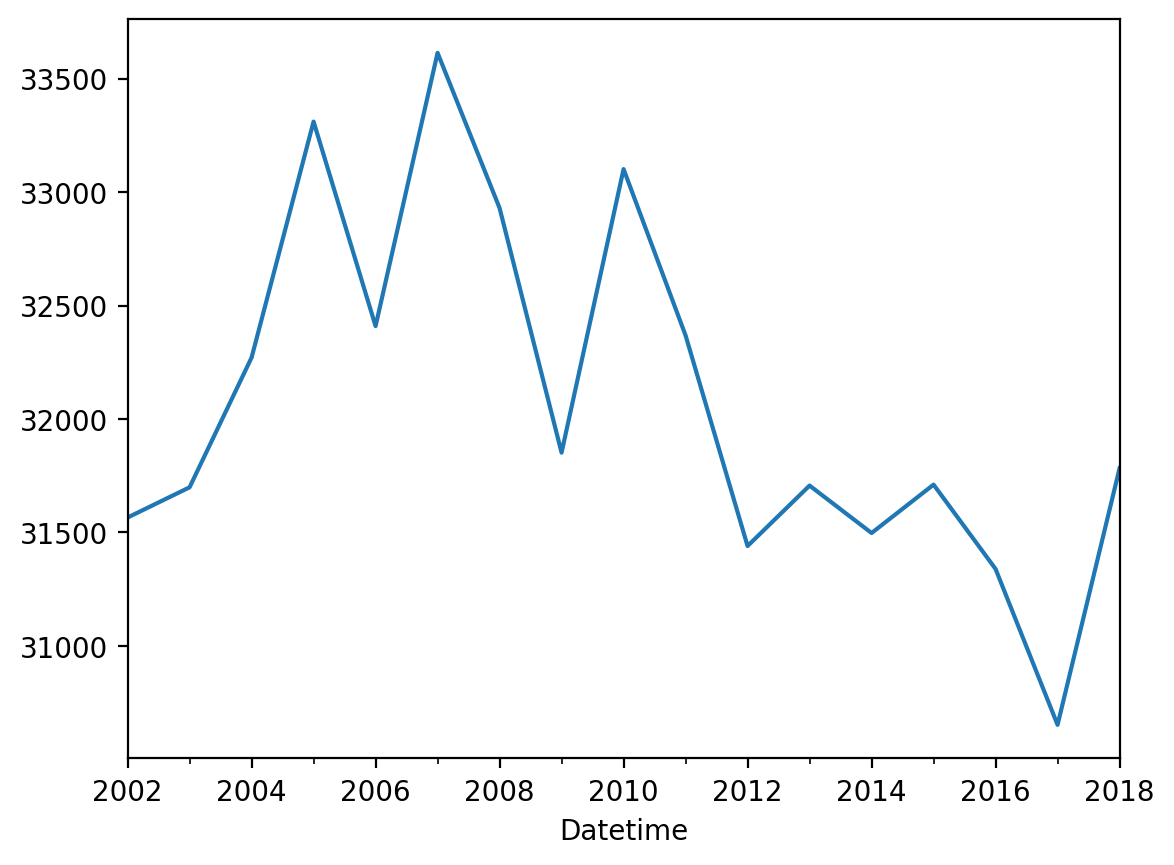

In [12]:
df["load"].resample('YE').mean().plot()
plt.show()

/tmp/ipykernel_213989/1352935677.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df["load"].resample('M').mean().plot()


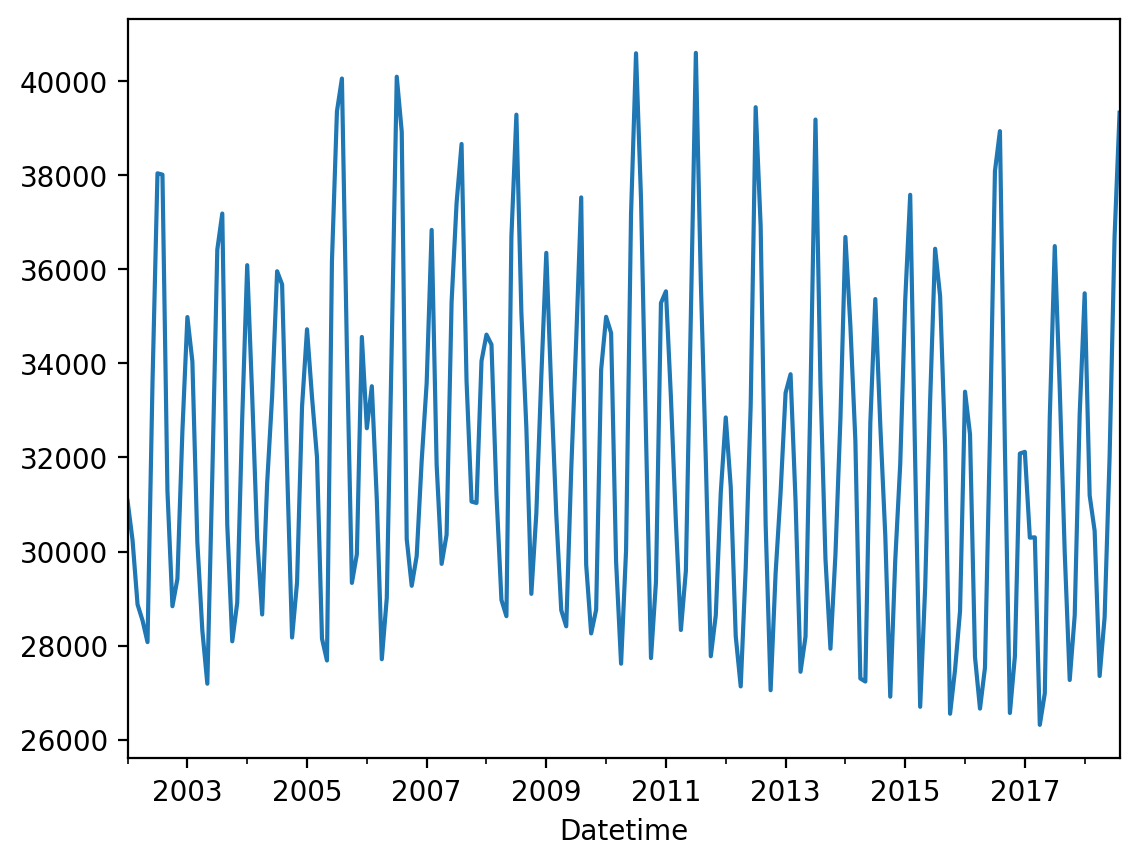

In [13]:
df["load"].resample('M').mean().plot()
plt.show()

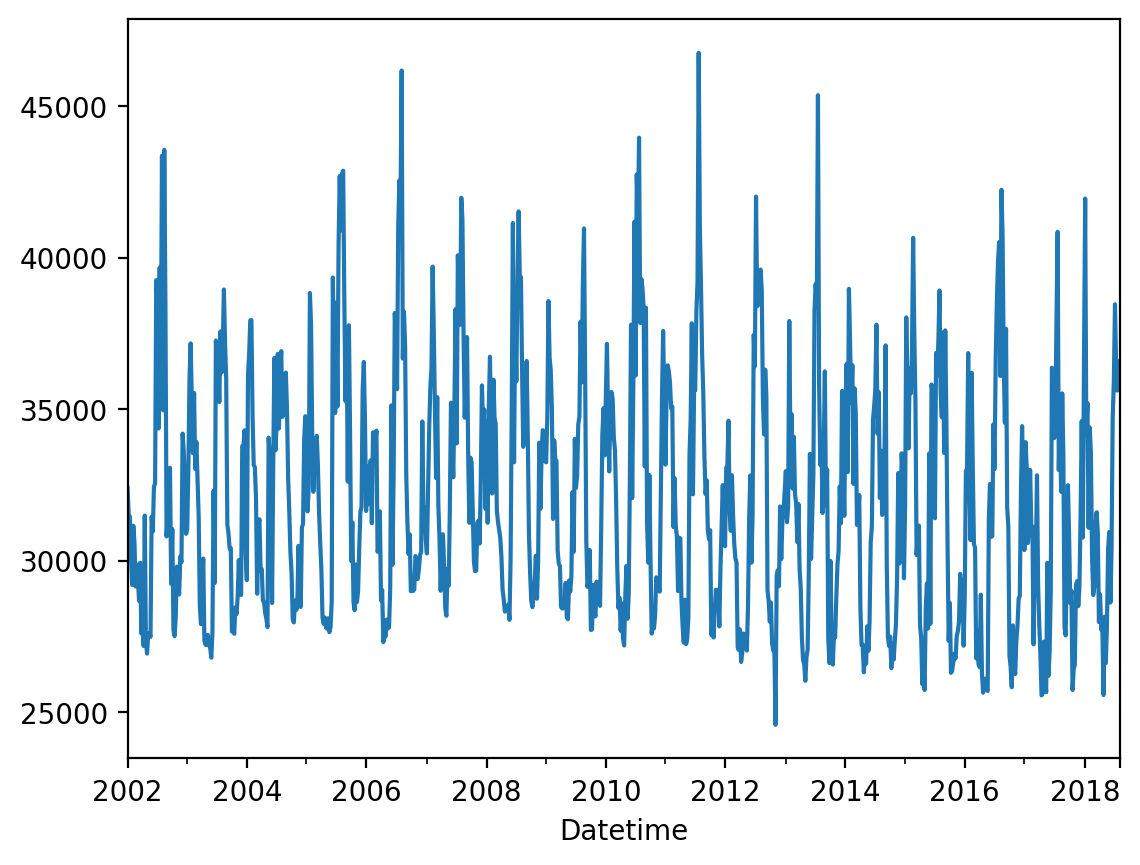

In [14]:
df["load"].resample('W').mean().plot()
plt.show()

# Baseline models with naive forecast no deep learing no statical machine learning models

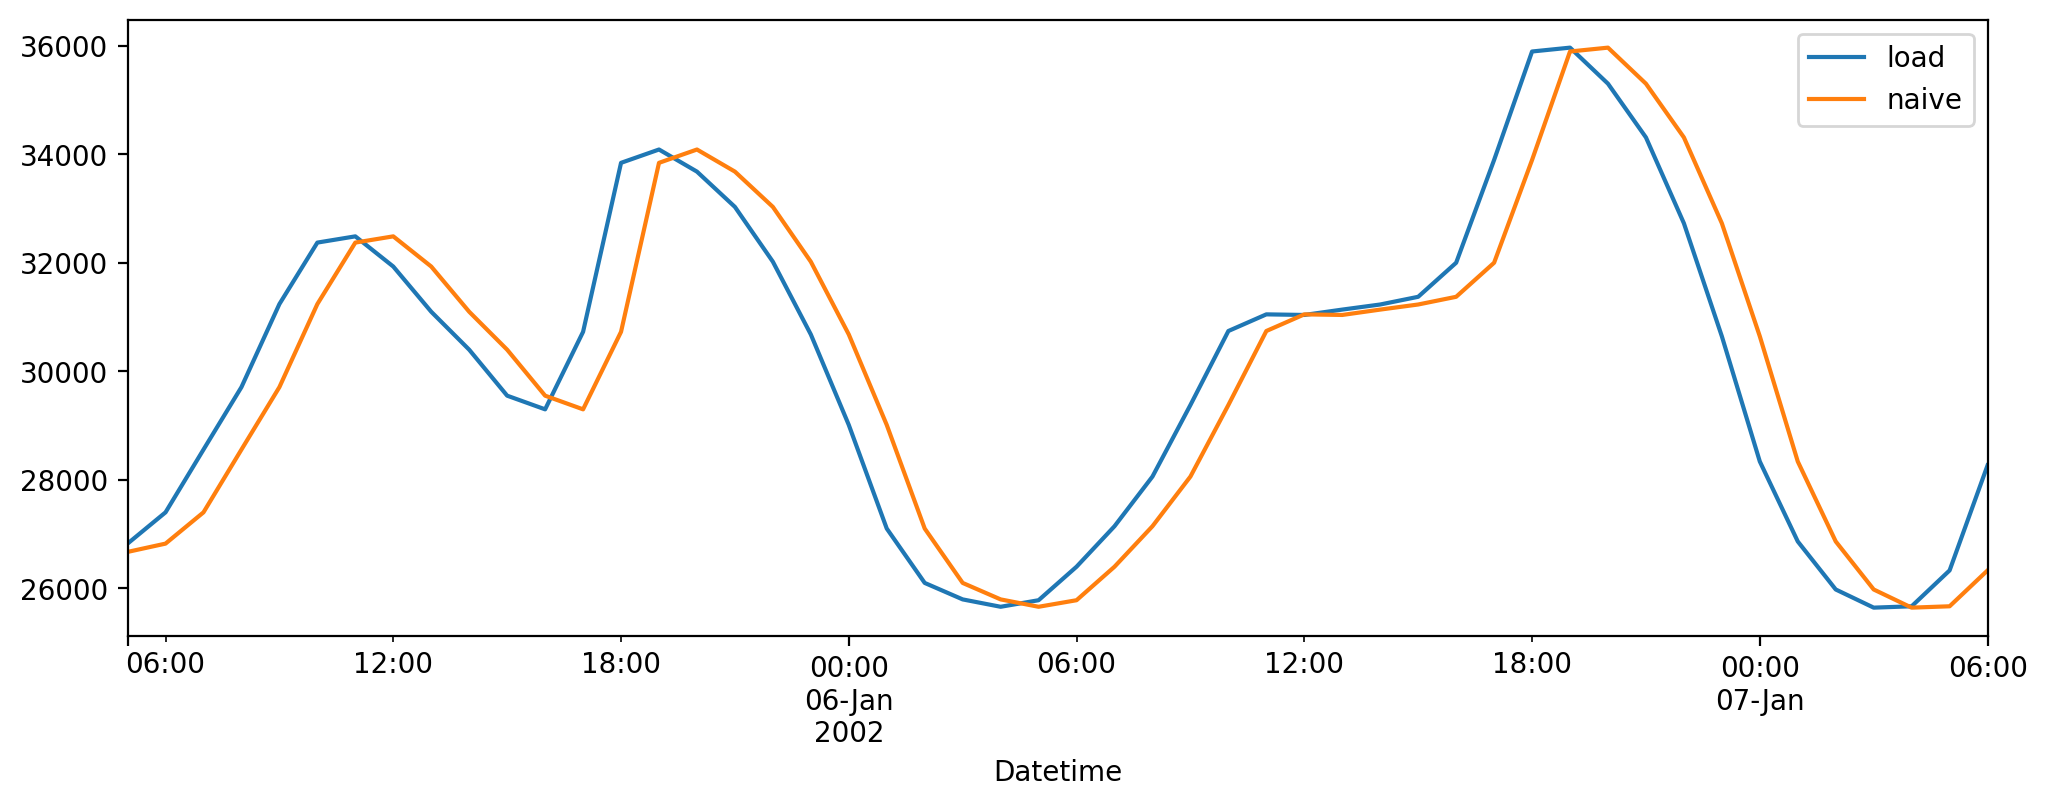

In [15]:
df['naive'] = df['load'].shift(1)
df[['load','naive']].iloc[100:150].plot(figsize=(12,4))
plt.show()

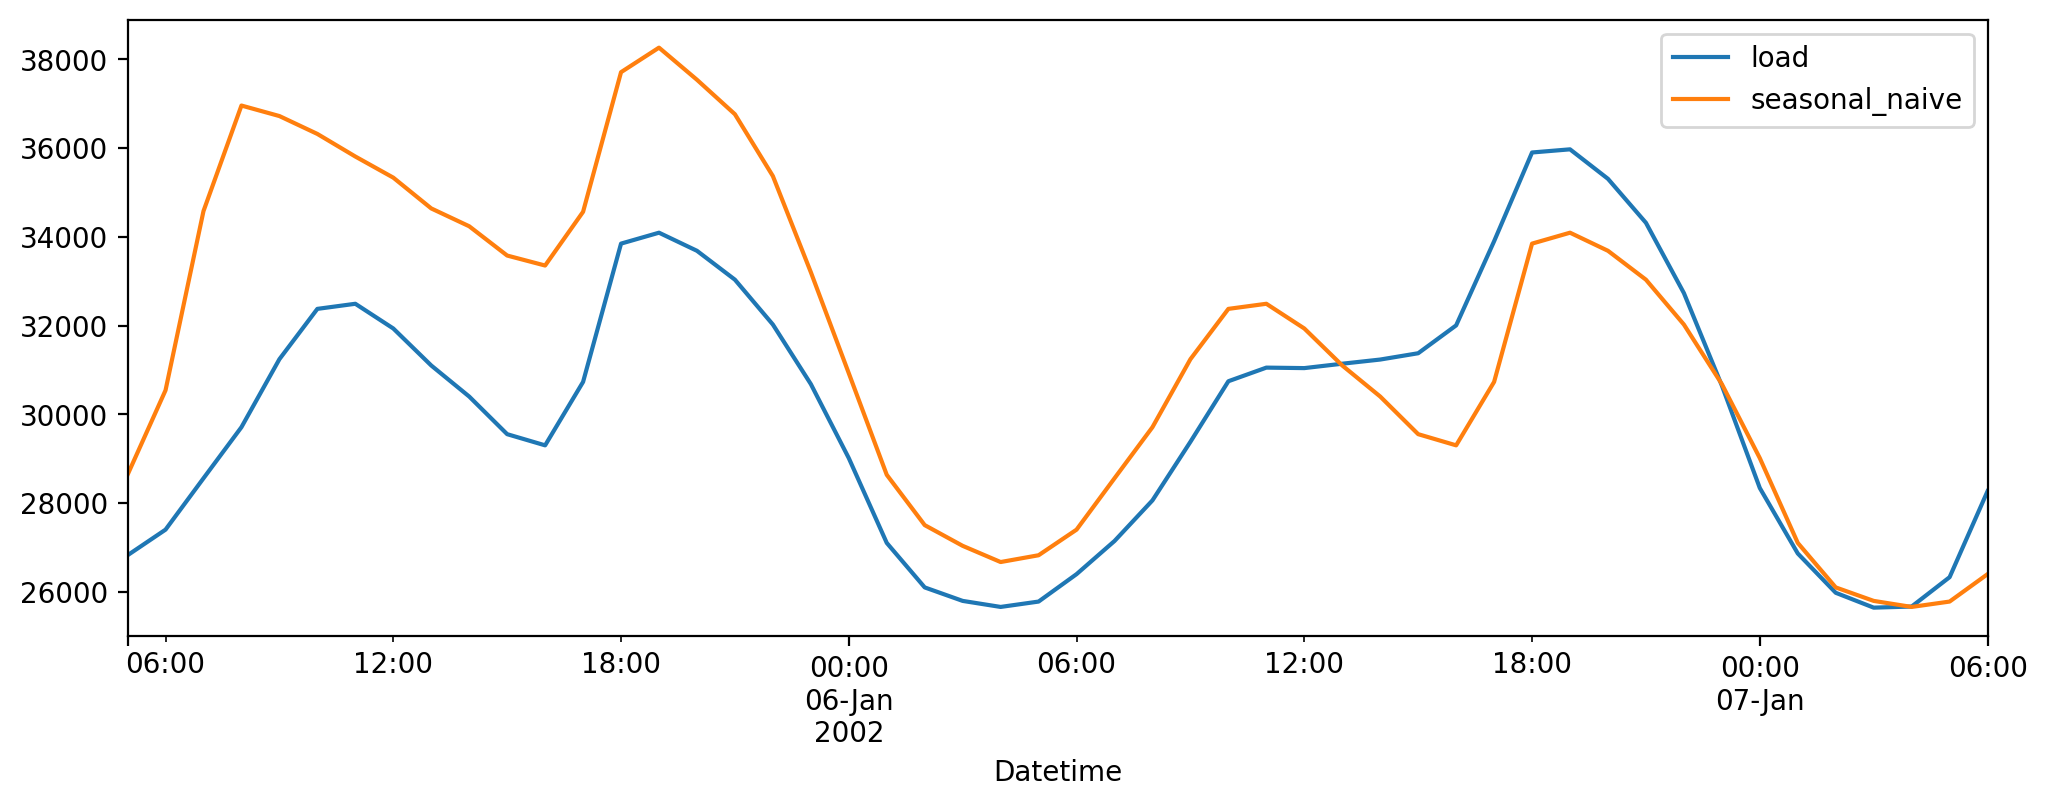

In [16]:
df['seasonal_naive'] = df['load'].shift(24)
df[['load','seasonal_naive']].iloc[100:150].plot(figsize=(12,4))
plt.show()

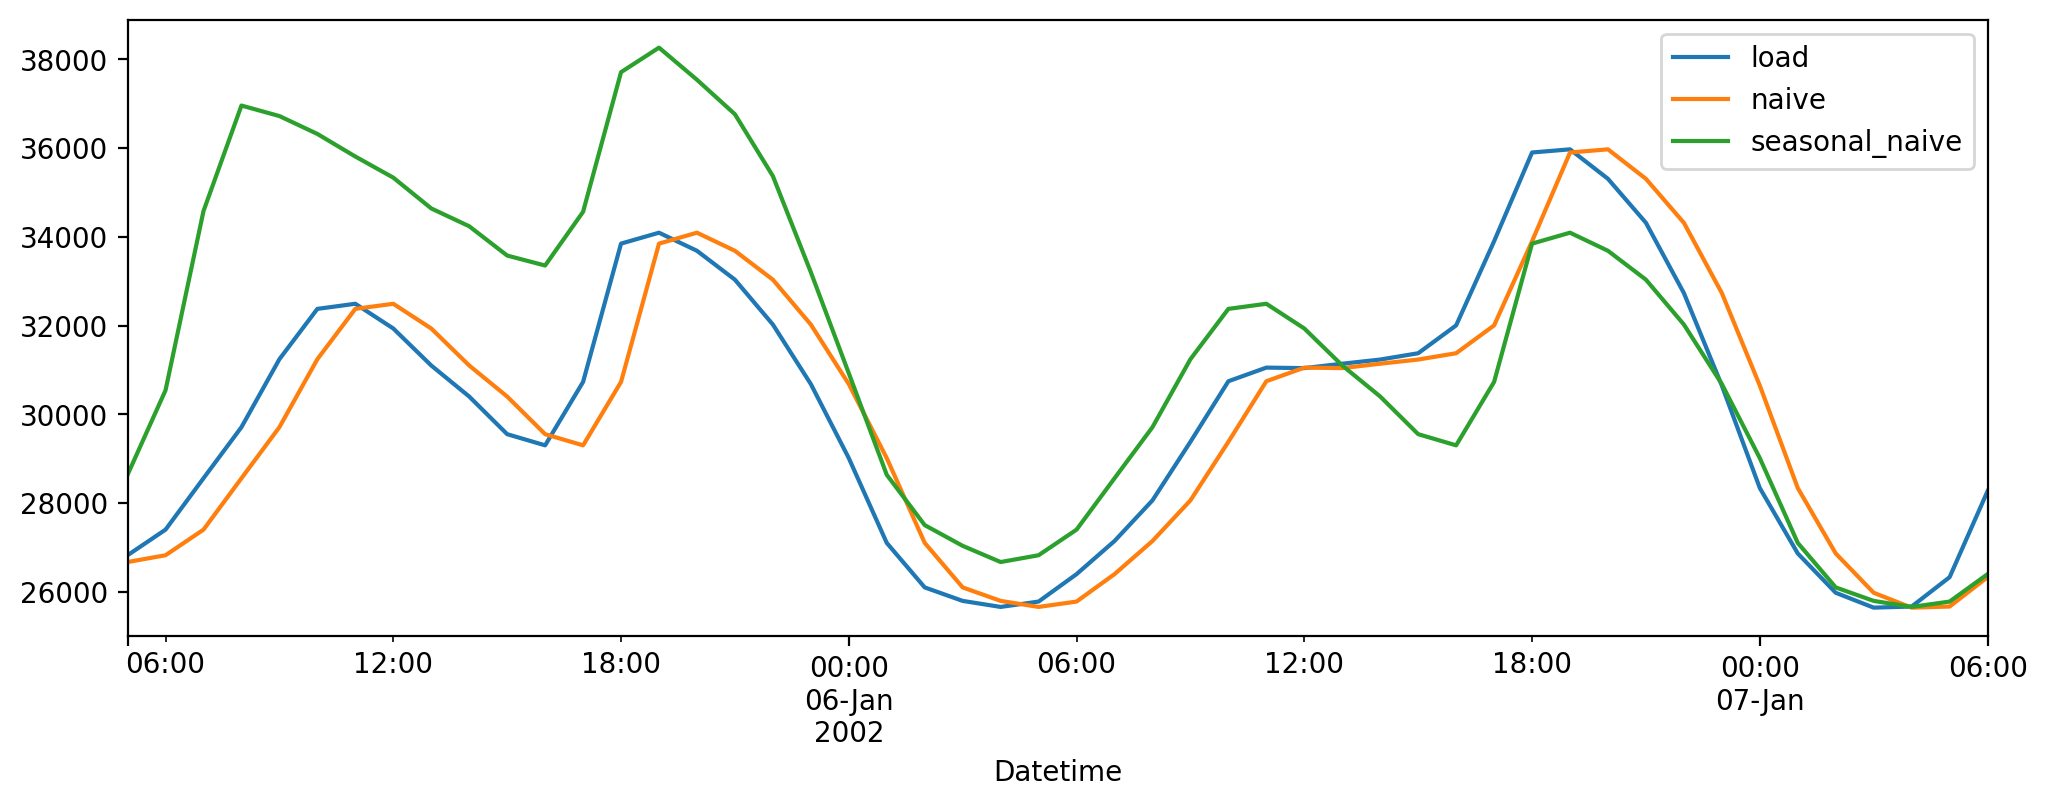

In [17]:
df[['load','naive','seasonal_naive']].iloc[100:150].plot(figsize=(12,4))
plt.show()

# Measuring accuracy of baseline 

# MAE

In [18]:
from sklearn.metrics import mean_absolute_error
mae_naive = mean_absolute_error(df["load"][24:], df["naive"][24:])
mae_seasonal = mean_absolute_error(df["load"][24:], df["seasonal_naive"][24:])

print("MAE Naive Forecast: {:.2f} MW".format(mae_naive))
print("MAE Seasonal Naive Forecast: {:.2f} MW".format(mae_seasonal))    

MAE Naive Forecast: 1109.52 MW
MAE Seasonal Naive Forecast: 2173.55 MW


# RMSE

In [19]:
from sklearn.metrics import root_mean_squared_error
rmse_naive = root_mean_squared_error(df["load"][24:], df["naive"][24:])
rmse_seasonal = root_mean_squared_error(df["load"][24:], df["seasonal_naive"][24:])
print("RMSE Naive Forecast: {:.2f} MW".format(rmse_naive))
print("RMSE Seasonal Naive Forecast: {:.2f} MW".format(rmse_seasonal))

RMSE Naive Forecast: 1452.21 MW
RMSE Seasonal Naive Forecast: 3012.63 MW


# MAPE

In [20]:
from sklearn.metrics import mean_absolute_percentage_error
mape_naive = mean_absolute_percentage_error(df["load"][24:], df["naive"][24:])
mape_seasonal = mean_absolute_percentage_error(df["load"][24:], df["seasonal_naive"][24:])
print("MAE Naive Forecast: {:.2f} MW".format(mae_naive))
print("RMSE Naive Forecast: {:.2f} MW".format(rmse_naive))
print("MAPE Naive Forecast: {:.2f}%".format(mape_naive * 100))
print("MAE Seasonal Naive Forecast: {:.2f} MW".format(mae_seasonal))    
print("RMSE Seasonal Naive Forecast: {:.2f} MW".format(rmse_seasonal))
print("MAPE Seasonal Naive Forecast: {:.2f}%".format(mape_seasonal * 100))  

MAE Naive Forecast: 1109.52 MW
RMSE Naive Forecast: 1452.21 MW
MAPE Naive Forecast: 3.53%
MAE Seasonal Naive Forecast: 2173.55 MW
RMSE Seasonal Naive Forecast: 3012.63 MW
MAPE Seasonal Naive Forecast: 6.71%


The "last hour" forecast works noticeably better than the "same hour yesterday" forecast. On average the one-hour method is off by about 1,110 MW (≈3.5%), while the daily-seasonal method is off by about 2,174 MW (≈6.7%) — so the hourly approach is roughly twice as accurate. This means recent immediate changes in demand matter more than simply repeating yesterday’s pattern. Next step: try more informed models to reduce these errors further.

In [33]:
df.to_csv("naive_baseline_results.csv",index=True)